In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Let $f(x)$ be a smooth and continuous function and $x_r$ be an unknown root of $f(x)$. Now assume that $x_0$ is a guess for $x_r$. Unless $x_0$ is a very lucky guess, $f(x_0)$ will not be a root. Given this scenario, we want to find an $x_1$ that is an improvement on $x_0$ (i.e., closer to $x_r$ than $x_0$). If we assume that $x_0$ is "close enough" to $x_r$, then we can improve upon it by taking the linear approximation of $f(x)$ around $x_0$, which is a line, and finding the intersection of this line with the x-axis. Written out, the linear approximation of $f(x)$ around $x_0$ is $f(x) \approx f(x_0) + f^{\prime}(x_0)(x-x_0)$. Using this approximation, we find $x_1$ such that $f(x_1) = 0$. Plugging these values into the linear approximation results in the equation

$$
0 = f(x_0) + f^{\prime}(x_0)(x_1-x_0),
$$
which when solved for $x_1$ is
$$
x_1 = x_0 - \frac{f(x_0)}{f^{\prime}(x_0)}.
$$
 


Written generally, a **Newton step** computes an improved guess, $x_i$, using a previous guess $x_{i-1}$, and is given by the equation

$$
x_i = x_{i-1} - \frac{g(x_{i-1})}{g^{\prime}(x_{i-1})}.
$$

The **Newton-Raphson Method** of finding roots iterates Newton steps from $x_0$ until the error is less than the tolerance.

**TRY IT!** Again, the $\sqrt{2}$ is the root of the function $f(x) = x^2 - 2$. Using $x_0 = 1.4$ as a starting point, use the previous equation to estimate $\sqrt{2}$. Compare this approximation with the value computed by Python's sqrt function.

$$
x = 1.4 - \frac{1.4^2 - 2}{2(1.4)} = 1.4142857142857144
$$

In [24]:
f = lambda x: x**2 - 2
df = lambda x: 2*x

def newtons_method (f, df, x0, tol):
    if abs(f(x0)) < tol:
        return x0
    else:
        return newtons_method(f, df, x0 - (f(x0)/df(x0)), tol)

estimate = newtons_method(f, df, 1.1, 1e-8)
print("estimate =", estimate)
print("sqrt(2) =", np.sqrt(2))

estimate = 1.4142135623731051
sqrt(2) = 1.4142135623730951


If $x_0$ is close to $x_r$, then it can be proven that, in general, the Newton-Raphson method converges to $x_r$ much faster than the bisection method. However since $x_r$ is initially unknown, there is no way to know if the initial guess is close enough to the root to get this behavior unless some special information about the function is known *a priori* (e.g., the function has a root close to $x = 0$). In addition to this initialization problem, the Newton-Raphson method has other serious limitations. For example, if the derivative at a guess is close to 0, then the Newton step will be very large and probably lead far away from the root. Also, depending on the behavior of the function derivative between $x_0$ and $x_r$, the Newton-Raphson method may converge to a different root than $x_r$ that may not be useful for our engineering application.

In [28]:
x0 = 20
x1 = x0-(x0**3+3*x0**2-2*x0-5)/(3*x0**2+6*x0-2)
print("x1 =", x1)

x1 = 13.053869499241275


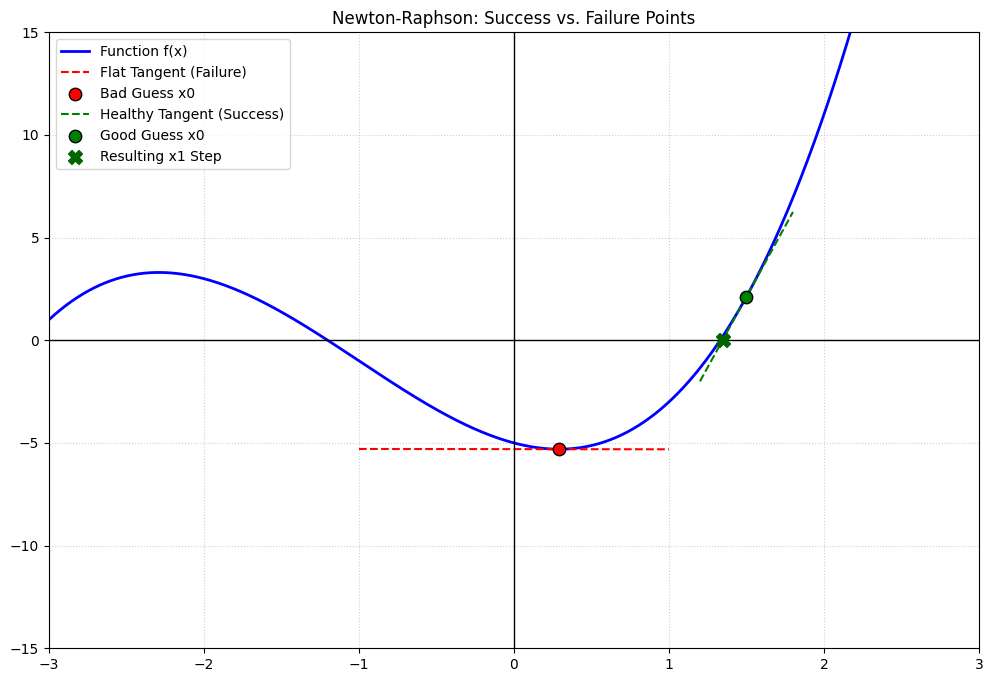

In [69]:
# AI generated graph code of this example

# 1. Define the function and its derivative
def f(x):
    return x**3 + 3*x**2 - 2*x - 5

def df(x):
    return 3*x**2 + 6*x - 2

# 2. Setup the math for the "Bad Guess" (x0 = 0.29)
x0_bad = 0.29
y0_bad = f(x0_bad)
slope_bad = df(x0_bad)
x1_bad = x0_bad - y0_bad / slope_bad  # Result is approx -688.45

# 3. Setup the math for the "Good Guess" (x0 = 1.5)
x0_good = 1.5
y0_good = f(x0_good)
slope_good = df(x0_good)
x1_good = x0_good - y0_good / slope_good # Result is approx 1.35

# 4. Create the plot
plt.figure(figsize=(12, 8))

# Define X range for the curve
x_vals = np.linspace(-3, 3, 1000)
y_vals = f(x_vals)

# Plot the main function curve
plt.plot(x_vals, y_vals, label='Function f(x)', color='blue', linewidth=2)

# --- Visualize the BAD GUESS ---
t_x_bad = np.linspace(-1, 1, 100)
t_y_bad = slope_bad * (t_x_bad - x0_bad) + y0_bad
plt.plot(t_x_bad, t_y_bad, '--', color='red', label='Flat Tangent (Failure)')
plt.scatter([x0_bad], [y0_bad], color='red', s=80, edgecolors='black', label='Bad Guess x0', zorder=5)

# --- Visualize the GOOD GUESS ---
t_x_good = np.linspace(1.2, 1.8, 100)
t_y_good = slope_good * (t_x_good - x0_good) + y0_good
plt.plot(t_x_good, t_y_good, '--', color='green', label='Healthy Tangent (Success)')
plt.scatter([x0_good], [y0_good], color='green', s=80, edgecolors='black', label='Good Guess x0', zorder=5)
plt.scatter([x1_good], [0], color='darkgreen', marker='X', s=100, label='Resulting x1 Step', zorder=5)

# --- Formatting ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.ylim(-15, 15)
plt.xlim(-3, 3)
plt.title('Newton-Raphson: Success vs. Failure Points')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [30]:
x0 = 0
x1 = x0 - ((x0**3 - 100*(x0**2) - x0 + 100) / (3*x0**2 - 200*x0 - 1))
print("x1 =", x1)

x1 = 100.0


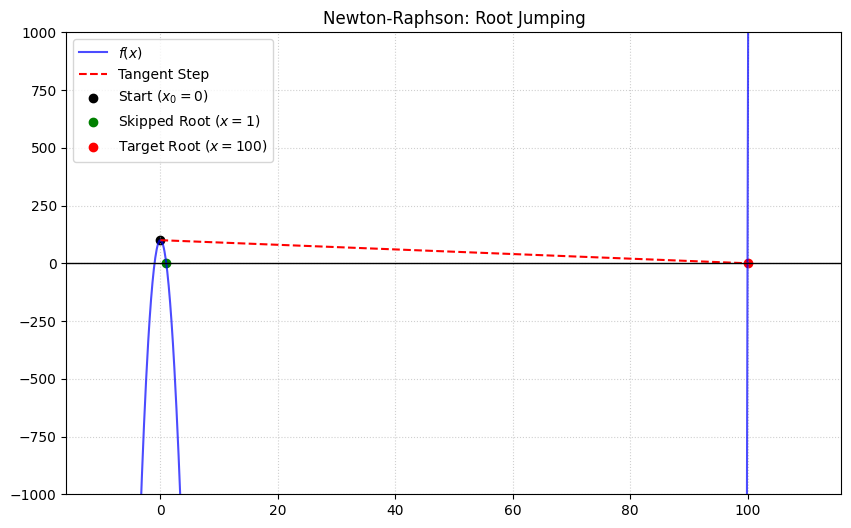

In [67]:
# AI generated graph code of this example

# Define function: f(x) = x^3 - 100x^2 - x + 100
def f(x):
    return x**3 - 100*x**2 - x + 100

# Define derivative: f'(x) = 3x^2 - 200x - 1
def df(x):
    return 3*x**2 - 200*x - 1

# Initial guess
x0 = 0
y0 = f(x0)
slope = df(x0)

# Newton step calculation
x1 = x0 - y0 / slope # Result is 100.0

# Plotting setup
x_vals = np.linspace(-10, 110, 1000)
y_vals = f(x_vals)

# Tangent line points (from x=0 to x=100)
t_x = np.array([0, 100])
t_y = slope * (t_x - x0) + y0

# Create plot
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label='$f(x)$', color='blue', alpha=0.7)
plt.plot(t_x, t_y, color='red', linestyle='--', label='Tangent Step')

# Mark points
plt.scatter([x0], [y0], color='black', label='Start ($x_0 = 0$)')
plt.scatter([1], [0], color='green', label='Skipped Root ($x = 1$)')
plt.scatter([100], [0], color='red', label='Target Root ($x = 100$)')

# Formatting
plt.ylim(-1000, 1000)
plt.axhline(0, color='black', linewidth=1)
plt.title('Newton-Raphson: Root Jumping')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.savefig('root_jumping_graph.png')

In [62]:
def newton_method(f, df, initial_guess, iterations):
    x0 = initial_guess

    data_list = []

    for i in range(1, iterations + 1):
        x0 = x0 - (f(x0)/df(x0))

        new_row = {'Guess': i,
                   'Estimate': x0}
        
        data_list.append(new_row)
    
    return pd.DataFrame(data_list).set_index('Guess')

f = lambda x: x ** 2 - 2
df = lambda x: 2*x
initial_guess = 2
iterations = 5

newton_method(f, df, initial_guess, iterations)

,Estimate
Guess,
1,1.500000
2,1.416667
3,1.414216
4,1.414214
5,1.414214
